In [1]:
!pip install requests pandas numpy matplotlib

In [2]:
import requests, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline
plt.style.use('dark_background')

## ⚙️ Settings

In [3]:
# ── TDI (best params) ────────────────────────────
RSI_PERIOD  = 10
BAND_LENGTH = 34
FAST_MA     = 7
SLOW_MA     = 2
BB_MULT     = 2.5

# ── Trail ─────────────────────────────────────────
TRAIL_PULLBACK = 0.0

# ── Position sizing ───────────────────────────────
BASE_MULT        = 1.0
TRIPLE_MULT      = 2.0
RSI_TRIPLE_LONG  = 20
RSI_TRIPLE_SHORT = 80

# ── Circuit breaker ───────────────────────────────
MONTHLY_LOSS_LIMIT = 300.0

# ── ADX regime filter ─────────────────────────────
ADX_PERIOD       = 14     # standard ADX period
ADX_TREND_THRESH = 30     # above this = trending market → block mean reversion
                           # below this = ranging market  → allow mean reversion
# Sweep will test 20, 25, 30, 35

# ── Backtest ──────────────────────────────────────
DAYS     = 912   # 2.5 years
CAPITAL  = 1000.0
FEE      = 0.001
SYMBOL   = 'SOLUSDT'
INTERVAL = '15m'

print(f"ADX filter: block trades when ADX > {ADX_TREND_THRESH} (trending market)")
print(f"Circuit breaker: ${MONTHLY_LOSS_LIMIT}/mo")
print(f"Triple sizing: {TRIPLE_MULT*100:.0f}% when RSI<={RSI_TRIPLE_LONG} or >={RSI_TRIPLE_SHORT}")

ADX filter: block trades when ADX > 30 (trending market)
Circuit breaker: $300.0/mo
Triple sizing: 200% when RSI<=20 or >=80


## 📥 Fetch 15M SOL data

In [4]:
def fetch_ohlcv(symbol, interval, days):
    ms  = {'5m':300_000,'15m':900_000,'1h':3_600_000}[interval]
    end = int(time.time() * 1000)
    cur = end - days * 86_400_000
    rows = []
    print(f"Fetching {interval} {symbol} ({days}d)...", end=" ")
    while cur < end:
        r = requests.get('https://api.binance.com/api/v3/klines',
            params={'symbol':symbol,'interval':interval,
                    'startTime':cur,'endTime':end,'limit':1000}, timeout=10)
        r.raise_for_status()
        data = r.json()
        if not data: break
        rows.extend(data)
        last = data[-1][0]
        if last <= cur or len(data) < 1000: break
        cur = last + ms
        time.sleep(0.1)
    df = pd.DataFrame(rows, columns=[
        'open_time','open','high','low','close','volume',
        'close_time','qv','trades','tb','tq','ignore'])
    df['ts']    = pd.to_datetime(df['open_time'], unit='ms', utc=True)
    df['close'] = df['close'].astype(float)
    df['high']  = df['high'].astype(float)
    df['low']   = df['low'].astype(float)
    df = df[['ts','high','low','close']].drop_duplicates('ts').sort_values('ts').reset_index(drop=True)
    print(f"{len(df):,} candles | {df['ts'].iloc[0].date()} -> {df['ts'].iloc[-1].date()} | latest: ${df['close'].iloc[-1]:.2f}")
    return df

df = fetch_ohlcv(SYMBOL, INTERVAL, DAYS)

Fetching 15m SOLUSDT (912d)... 87,552 candles | 2023-11-19 -> 2026-05-19 | latest: $85.13


## 📐 TDI + ADX Calculation

**ADX formula (Wilder's method — same as TradingView):**
1. True Range (TR) = max(high-low, |high-prev_close|, |low-prev_close|)
2. +DM = high - prev_high if positive and > (prev_low - low), else 0
3. -DM = prev_low - low if positive and > (high - prev_high), else 0
4. Smooth TR, +DM, -DM with Wilder's RMA (alpha=1/period)
5. +DI = 100 × smoothed +DM / smoothed TR
6. -DI = 100 × smoothed -DM / smoothed TR
7. DX  = 100 × |+DI - -DI| / (+DI + -DI)
8. ADX = RMA(DX, period)

**Regime logic:**
- ADX < threshold → ranging market → mean reversion allowed ✅
- ADX > threshold → trending market → skip new entries ❌

In [5]:
def calc_rsi(close, period):
    """Wilder's RSI — matches Pine Script exactly."""
    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_g = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_l = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs    = avg_g / avg_l.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def calc_adx(df, period=14):
    """Wilder's ADX — matches Pine Script ta.adx() exactly."""
    df = df.copy()
    hi  = df['high']
    lo  = df['low']
    cl  = df['close']

    # True Range
    tr  = pd.concat([
        hi - lo,
        (hi - cl.shift(1)).abs(),
        (lo - cl.shift(1)).abs()
    ], axis=1).max(axis=1)

    # Directional movement
    up   = hi - hi.shift(1)
    down = lo.shift(1) - lo
    plus_dm  = np.where((up > down) & (up > 0),   up,   0.0)
    minus_dm = np.where((down > up) & (down > 0), down, 0.0)

    plus_dm  = pd.Series(plus_dm,  index=df.index)
    minus_dm = pd.Series(minus_dm, index=df.index)

    # Wilder's smoothing (RMA)
    atr      = tr.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    plus_di  = 100 * plus_dm.ewm(alpha=1/period, min_periods=period, adjust=False).mean() / atr
    minus_di = 100 * minus_dm.ewm(alpha=1/period, min_periods=period, adjust=False).mean() / atr

    dx  = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    adx = dx.ewm(alpha=1/period, min_periods=period, adjust=False).mean()

    df['atr']      = atr
    df['+di']      = plus_di
    df['-di']      = minus_di
    df['adx']      = adx
    df['trending'] = adx > ADX_TREND_THRESH   # True = trending, block trades
    return df

def calc_tdi(df):
    df = df.copy()
    df['r']       = calc_rsi(df['close'], RSI_PERIOD)
    df['ma']      = df['r'].rolling(BAND_LENGTH).mean()
    df['std']     = df['r'].rolling(BAND_LENGTH).std(ddof=0)
    df['up']      = df['ma'] + BB_MULT * df['std']
    df['dn']      = df['ma'] - BB_MULT * df['std']
    df['mid']     = (df['up'] + df['dn']) / 2
    df['baseline']= df['ma'].copy()
    df['mbb']     = df['r'].rolling(FAST_MA).mean()
    df['mab']     = df['r'].rolling(SLOW_MA).mean()
    df['r_prev']  = df['r'].shift(1)
    df['up_prev'] = df['up'].shift(1)
    df['dn_prev'] = df['dn'].shift(1)
    # Hook fires when RSI crosses BACK INSIDE the band (matches TradingView visual)
    # upper hook down: prev bar RSI was above upper band, current bar RSI crossed below upper band
    # lower hook up:   prev bar RSI was below lower band, current bar RSI crossed above lower band
    df['upper_hook_down'] = (df['r_prev'] >= df['up_prev']) & (df['r'] < df['up'])
    df['lower_hook_up']   = (df['r_prev'] <= df['dn_prev']) & (df['r'] > df['dn'])
    return df

# Calculate both
tdi = calc_tdi(df)
tdi = calc_adx(tdi, ADX_PERIOD)

# Stats
trending_pct = tdi['trending'].mean() * 100
ranging_pct  = 100 - trending_pct
row = tdi.iloc[-1]
print(f"Current ADX: {row['adx']:.1f} | +DI: {row['+di']:.1f} | -DI: {row['-di']:.1f}")
print(f"Current regime: {'TRENDING ❌ (no new trades)' if row['trending'] else 'RANGING ✅ (trades allowed)'}")
print(f"\nOver the past year:")
print(f"  Trending (ADX > {ADX_TREND_THRESH}): {trending_pct:.1f}% of bars")
print(f"  Ranging  (ADX < {ADX_TREND_THRESH}): {ranging_pct:.1f}% of bars")

Current ADX: 9.5 | +DI: 19.0 | -DI: 26.6
Current regime: RANGING ✅ (trades allowed)

Over the past year:
  Trending (ADX > 30): 30.6% of bars
  Ranging  (ADX < 30): 69.4% of bars


## 🔁 Backtest — 3 versions

| Version | ADX filter | CB | Triple sizing |
|---|---|---|---|
| A — Baseline (best from before) | No | Yes $150 | Yes 200% |
| B — ADX filter only | Yes | No | Yes 200% |
| C — ADX filter + CB | Yes | Yes $150 | Yes 200% |

**ADX filter rule:**
- When ADX > threshold → market is trending → skip ALL new entries
- When ADX < threshold → market is ranging → allow mean reversion entries as normal
- If already IN a trade when ADX spikes → stay in, let trail exit handle it

In [6]:
def backtest(df, use_adx=False, monthly_limit=None):
    trades   = []
    position = None
    entry_price = entry_time = entry_mult = entry_rsi_level = None
    equity = CAPITAL
    peak   = CAPITAL

    hook_rsi_level = None
    waiting_trail  = False

    current_month  = None
    month_pnl      = 0.0
    breaker_on     = False
    breaker_months = []

    def get_mult(direction, entry_rsi):
        if direction == 'long'  and entry_rsi <= RSI_TRIPLE_LONG:  return TRIPLE_MULT
        if direction == 'short' and entry_rsi >= RSI_TRIPLE_SHORT: return TRIPLE_MULT
        return BASE_MULT

    def close_trade(exit_price, forced=False):
        nonlocal equity, peak, month_pnl
        gross    = (exit_price - entry_price)/entry_price if position=='long'                    else (entry_price - exit_price)/entry_price
        net      = gross - 2*FEE
        notional = equity * entry_mult
        pnl      = notional * net
        equity    += pnl
        month_pnl += pnl
        peak       = max(peak, equity)
        dd         = (peak - equity) / peak * 100
        trades.append({
            'direction':   position,
            'entry_time':  entry_time,
            'exit_time':   ts,
            'entry_price': entry_price,
            'exit_price':  exit_price,
            'multiplier':  entry_mult,
            'tripled':     entry_mult == TRIPLE_MULT,
            'entry_rsi':   round(entry_rsi_level, 2) if entry_rsi_level else None,
            'net_ret_pct': round(net*100, 3),
            'pnl_usd':     round(pnl, 2),
            'equity':      round(equity, 2),
            'dd_pct':      round(dd, 2),
            'forced':      forced,
            'adx_at_entry': round(row['adx'], 2) if 'adx' in row else None,
        })
        return pnl

    def open_trade(direction, entry_rsi):
        nonlocal position, entry_price, entry_time, entry_mult, entry_rsi_level
        position        = direction
        entry_price     = price
        entry_time      = ts
        entry_mult      = get_mult(direction, entry_rsi)
        entry_rsi_level = entry_rsi

    for _, row in df.iterrows():
        if pd.isna(row['r']) or pd.isna(row['up']): continue
        if use_adx and pd.isna(row['adx']): continue

        price = row['close']
        ts    = row['ts']
        rsi   = row['r']
        month = ts.to_period('M')

        # ADX regime check — only blocks NEW entries, not existing trades
        is_trending = use_adx and row['trending']

        # ── Month reset ──
        if month != current_month:
            if breaker_on: breaker_months.append(str(current_month))
            current_month = month
            month_pnl     = 0.0
            breaker_on    = False

        # ── Force close if breaker hit ──
        if monthly_limit and not breaker_on:
            if month_pnl <= -monthly_limit and position is not None:
                close_trade(price, forced=True)
                position       = None
                waiting_trail  = False
                hook_rsi_level = None
                breaker_on     = True
                continue

        if breaker_on: continue
        if monthly_limit and month_pnl <= -monthly_limit:
            breaker_on = True; continue

        # ── State machine ──
        if position is None:
            waiting_trail = False; hook_rsi_level = None
            if not is_trending:   # only enter in ranging market
                if row['upper_hook_down']:
                    open_trade('short', row['r_prev'])
                elif row['lower_hook_up']:
                    open_trade('long',  row['r_prev'])

        elif position == 'long':
            if not waiting_trail and row['upper_hook_down']:
                waiting_trail  = True
                hook_rsi_level = row['r_prev']
            elif waiting_trail and rsi <= hook_rsi_level - TRAIL_PULLBACK:
                close_trade(price)
                waiting_trail = False; hook_rsi_level = None
                if not (monthly_limit and month_pnl <= -monthly_limit):
                    if not is_trending:
                        open_trade('short', row['r_prev'])
                    else:
                        position = None   # flat — wait for ranging regime
                else:
                    position = None; breaker_on = True

        elif position == 'short':
            if not waiting_trail and row['lower_hook_up']:
                waiting_trail  = True
                hook_rsi_level = row['r_prev']
            elif waiting_trail and rsi >= hook_rsi_level + TRAIL_PULLBACK:
                close_trade(price)
                waiting_trail = False; hook_rsi_level = None
                if not (monthly_limit and month_pnl <= -monthly_limit):
                    if not is_trending:
                        open_trade('long', row['r_prev'])
                    else:
                        position = None
                else:
                    position = None; breaker_on = True

    t = pd.DataFrame(trades)
    if len(t):
        t['cum_max']      = t['equity'].cummax()
        t['dd_from_peak'] = (t['cum_max'] - t['equity']) / t['cum_max'] * 100
    return t, equity, breaker_months

print("Running 3 scenarios...")
t_A, eq_A, bm_A = backtest(tdi, use_adx=False, monthly_limit=MONTHLY_LOSS_LIMIT)
t_B, eq_B, bm_B = backtest(tdi, use_adx=True,  monthly_limit=None)
t_C, eq_C, bm_C = backtest(tdi, use_adx=True,  monthly_limit=MONTHLY_LOSS_LIMIT)
print("Done")

Running 3 scenarios...


/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')


Done


## 📊 Performance summary

In [15]:
def print_stats(label, t, eq, bm):
    if len(t) == 0:
        print(f"  {label}: no trades"); return
    wins    = t[t['pnl_usd'] > 0]
    losses  = t[t['pnl_usd'] <= 0]
    longs   = t[t['direction'] == 'long']
    shorts  = t[t['direction'] == 'short']
    tripled = t[t['tripled'] == True] if 'tripled' in t.columns else pd.DataFrame()
    wr      = len(wins)/len(t)*100
    avg_w   = wins['pnl_usd'].mean()   if len(wins)   else 0
    avg_l   = losses['pnl_usd'].mean() if len(losses) else 0
    rr      = abs(avg_w/avg_l)         if avg_l != 0  else float('inf')
    ret     = (eq - CAPITAL) / CAPITAL * 100
    mdd     = t['dd_from_peak'].max()
    lw      = len(longs[longs['pnl_usd']>0])/len(longs)*100   if len(longs)  else 0
    sw      = len(shorts[shorts['pnl_usd']>0])/len(shorts)*100 if len(shorts) else 0

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  Trades        {len(t)}  ({len(longs)} longs / {len(shorts)} shorts)")
    if len(tripled): print(f"  Tripled       {len(tripled)} trades ({len(tripled)/len(t)*100:.1f}%)")
    if bm:           print(f"  Breaker fired {bm}")
    print(f"  Long WR       {lw:.1f}%   |  Short WR: {sw:.1f}%")
    print(f"  Overall WR    {wr:.1f}%")
    print(f"  Avg win       ${avg_w:+.2f}  |  Avg loss: ${avg_l:.2f}")
    print(f"  RR            {rr:.3f}x")
    print(f"  Return        {ret:+.2f}%  (${CAPITAL:,.0f} -> ${eq:,.2f})")
    print(f"  Max DD        {mdd:.2f}%")

print_stats(f'A — No ADX filter + CB ${MONTHLY_LOSS_LIMIT:.0f}', t_A, eq_A, bm_A)
print_stats(f'B — ADX = {ADX_TREND_THRESH}, no CB',                          t_B, eq_B, bm_B)
print_stats(f'C — ADX = {ADX_TREND_THRESH}, filter + CB ${MONTHLY_LOSS_LIMIT:.0f}',                       t_C, eq_C, bm_C)


  A — No ADX filter + CB $300
  Trades        446  (220 longs / 226 shorts)
  Tripled       44 trades (9.9%)
  Breaker fired ['2024-02', '2024-08', '2024-10', '2025-01', '2025-03', '2025-06', '2025-07', '2025-08', '2025-09', '2026-02']
  Long WR       56.8%   |  Short WR: 56.2%
  Overall WR    56.5%
  Avg win       $+159.65  |  Avg loss: $-148.01
  RR            1.079x
  Return        +1151.83%  ($1,000 -> $12,518.30)
  Max DD        66.94%

  B — ADX = 30, no CB
  Trades        463  (231 longs / 232 shorts)
  Tripled       34 trades (7.3%)
  Long WR       58.0%   |  Short WR: 56.9%
  Overall WR    57.5%
  Avg win       $+131.65  |  Avg loss: $-132.83
  RR            0.991x
  Return        +885.02%  ($1,000 -> $9,850.24)
  Max DD        55.10%

  C — ADX = 30, filter + CB $300
  Trades        340  (166 longs / 174 shorts)
  Tripled       26 trades (7.6%)
  Breaker fired ['2024-02', '2024-10', '2024-12', '2025-01', '2025-03', '2025-06', '2025-07', '2025-08', '2025-10', '2026-02', '2026

## 📅 Monthly breakdown — did ADX help in Feb 2026?

In [8]:
rows = []
for label, t in [('A_noadx', t_A), ('B_adx_noCB', t_B), ('C_adx_CB', t_C)]:
    if len(t) == 0: continue
    tc = t.copy()
    tc['month'] = tc['exit_time'].dt.to_period('M')
    m = tc.groupby('month').agg(
        trades=('pnl_usd','count'),
        pnl=('pnl_usd','sum'),
        wins=('pnl_usd', lambda x:(x>0).sum()),
    ).reset_index()
    m['wr']    = (m['wins']/m['trades']*100).round(1)
    m['label'] = label
    rows.append(m)

combined = pd.concat(rows)
pivot = combined.pivot_table(
    index='month', columns='label', values='pnl', aggfunc='first').round(0)
pivot.columns.name = None
pivot = pivot.reset_index()
for col in ['A_noadx','B_adx_noCB','C_adx_CB']:
    if col in pivot.columns:
        pivot[col] = pivot[col].map(lambda x: f'${x:+.0f}')

print("Monthly PnL — A(no ADX) | B(ADX/noCB) | C(ADX+CB)")
print("Focus on Feb 2026 — did ADX block the losing trades?")
print(pivot.to_string(index=False))

Monthly PnL — A(no ADX) | B(ADX/noCB) | C(ADX+CB)
Focus on Feb 2026 — did ADX block the losing trades?
  month A_noadx B_adx_noCB C_adx_CB
2023-11   $+253      $+253    $+253
2023-12   $-230      $+145    $+145
2024-01   $-107       $+68     $+68
2024-02   $-301      $-160    $-303
2024-03   $+359      $+184    $+502
2024-04   $+196       $-34     $-38
2024-05    $+80       $-59     $-65
2024-06   $+107       $-99    $-111
2024-07   $+375      $+663    $+741
2024-08   $-362      $+212    $+237
2024-09   $+631      $+385    $+430
2024-10   $-301      $-326    $-337
2024-11  $+1287      $+787   $+1033
2024-12   $-254      $-151    $-331
2025-01   $-303      $-986    $-553
2025-02   $+674      $+327   $+1023
2025-03   $-423      $-614    $-378
2025-04  $+1835      $+889   $+1802
2025-05  $+1057      $+628   $+1294
2025-06   $-510       $-78    $-541
2025-07   $-442      $-262    $-487
2025-08   $-387      $-216    $-309
2025-09   $-310      $+503    $+918
2025-10  $+2842     $+1530    $-4

/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/427496785.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tc['month'] = tc['exit_time'].dt.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/427496785.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tc['month'] = tc['exit_time'].dt.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/427496785.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tc['month'] = tc['exit_time'].dt.to_period('M')


## 🔧 ADX threshold sweep

In [9]:
print("Sweeping ADX thresholds...")
sweep = []
for thresh in [15, 20, 25, 30, 35, 40]:
    # Recalculate ADX with this threshold
    tdi2 = tdi.copy()
    tdi2['trending'] = tdi2['adx'] > thresh

    for use_cb, cb_label in [(False,'no CB'), (True, f'CB ${MONTHLY_LOSS_LIMIT:.0f}')]:
        t, eq, bm = backtest(tdi2, use_adx=True,
                             monthly_limit=MONTHLY_LOSS_LIMIT if use_cb else None)
        if len(t) == 0: continue
        wins   = t[t['pnl_usd']>0]; losses = t[t['pnl_usd']<=0]
        wr     = len(wins)/len(t)*100
        avg_w  = wins['pnl_usd'].mean()   if len(wins)   else 0
        avg_l  = losses['pnl_usd'].mean() if len(losses) else 0
        rr     = abs(avg_w/avg_l)         if avg_l       else float('inf')
        ret    = (eq-CAPITAL)/CAPITAL*100
        mdd    = t['dd_from_peak'].max()
        blocked= int((tdi2['trending'] & (tdi2['upper_hook_down'] | tdi2['lower_hook_up'])).sum())
        sweep.append({
            'adx_thresh':   thresh,
            'circuit_breaker': cb_label,
            'trades':       len(t),
            'blocked':      blocked,
            'win_rate':     round(wr,1),
            'rr':           round(rr,3),
            'total_return': round(ret,2),
            'max_dd':       round(mdd,2),
            'final_equity': round(eq,2),
        })

sweep_df = pd.DataFrame(sweep)
for cb in ['no CB', f'CB ${MONTHLY_LOSS_LIMIT:.0f}']:
    print(f"\n── ADX sweep — {cb} ──")
    sub = sweep_df[sweep_df['circuit_breaker']==cb].drop(columns='circuit_breaker')
    print(sub.to_string(index=False))

Sweeping ADX thresholds...


/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipyker


── ADX sweep — no CB ──
 adx_thresh  trades  blocked  win_rate    rr  total_return  max_dd  final_equity
         15      71     1185      60.6 0.861         34.00   19.25       1339.96
         20     221      946      61.5 0.845        505.92   37.48       6059.15
         25     374      648      58.3 0.883        266.55   51.13       3665.52
         30     463      390      57.5 0.991        885.02   55.10       9850.24
         35     521      214      56.8 0.959        956.94   67.89      10569.36
         40     551      116      57.2 0.941        851.99   73.90       9519.87

── ADX sweep — CB $300 ──
 adx_thresh  trades  blocked  win_rate    rr  total_return  max_dd  final_equity
         15      71     1185      60.6 0.861         34.00   19.25       1339.96
         20     162      946      61.7 0.913        508.45   31.64       6084.47
         25     332      648      57.2 0.959        263.48   59.44       3634.76
         30     340      390      59.1 1.041       1117.5

## 📈 Charts — ADX regime + equity curves

## 🔧 Trail pullback sweep

In [18]:
# ── Trail sweep ────────────────────────────────────────────────────────────
print(f'Sweeping trail pullback levels (ADX={ADX_TREND_THRESH}, CB={MONTHLY_LOSS_LIMIT:.0f})...')
trail_sweep = []
for trail in [0, 2, 3, 5, 7, 8, 10, 12, 15, 20]:
    globals()['TRAIL_PULLBACK'] = trail
    t, eq, bm = backtest(tdi, use_adx=True, monthly_limit=MONTHLY_LOSS_LIMIT)
    if len(t) == 0: continue
    wins   = t[t['pnl_usd']>0]; losses = t[t['pnl_usd']<=0]
    wr     = len(wins)/len(t)*100
    avg_w  = wins['pnl_usd'].mean()   if len(wins)   else 0
    avg_l  = losses['pnl_usd'].mean() if len(losses) else 0
    rr     = abs(avg_w/avg_l)         if avg_l       else float('inf')
    ret    = (eq-CAPITAL)/CAPITAL*100
    mdd    = t['dd_from_peak'].max()
    cagr   = ((eq/CAPITAL)**(1/2.5)-1)*100
    ratio  = ret/mdd if mdd > 0 else 0
    trail_sweep.append({
        'trail_pts':      trail,
        'trades':         len(t),
        'win_rate':       round(wr,1),
        'avg_win':        round(avg_w,2),
        'avg_loss':       round(avg_l,2),
        'rr':             round(rr,3),
        'total_return':   round(ret,2),
        'cagr_pct':       round(cagr,1),
        'max_dd':         round(mdd,2),
        'return_dd_ratio':round(ratio,2),
        'final_equity':   round(eq,2),
    })

globals()['TRAIL_PULLBACK'] = 0.0  # reset to default
trail_df = pd.DataFrame(trail_sweep)
print(f'\n── Trail sweep — ADX={ADX_TREND_THRESH}, CB=${MONTHLY_LOSS_LIMIT:.0f}, 2.5yr ──')
print(trail_df.to_string(index=False))
print("\nReturn/DD ratio:")
for _, row in trail_df.iterrows():
    print(f"  {row['trail_pts']}pt: {row['total_return']:+.1f}% / {row['max_dd']:.1f}% DD = {row['return_dd_ratio']:.2f}x | CAGR {row['cagr_pct']:.1f}%")


Sweeping trail pullback levels (ADX=30, CB=300)...


/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipyker


── Trail sweep — ADX=30, CB=$300, 2.5yr ──
 trail_pts  trades  win_rate  avg_win  avg_loss    rr  total_return  cagr_pct  max_dd  return_dd_ratio  final_equity
         0     340      59.1   165.56   -159.00 1.041       1117.59     171.8   33.12            33.74      12175.90
         2     368      57.1   142.06   -123.30 1.152       1035.18     164.3   36.47            28.39      11351.83
         3     374      57.5   116.43   -103.52 1.125        857.17     146.8   43.83            19.56       9571.67
         5     377      57.3    99.28    -90.27 1.100        691.06     128.7   45.77            15.10       7910.65
         7     370      58.6   113.15   -103.81 1.090        867.13     147.9   41.56            20.87       9671.28
         8     372      58.9   106.52   -100.28 1.062        798.54     140.7   46.25            17.27       8985.40
        10     387      56.3    69.66    -69.57 1.001        342.81      81.3   53.45             6.41       4428.08
        12     367  

## 🔧 Circuit breaker sweep

In [20]:
# ── Circuit breaker sweep ───────────────────────────────────────────────────
# Use best trail from above — update BEST_TRAIL after running trail sweep
BEST_TRAIL = 0.0   # update this after trail sweep

globals()['TRAIL_PULLBACK'] = BEST_TRAIL
print(f"Sweeping CB limits (trail={BEST_TRAIL}, ADX={ADX_TREND_THRESH})...")
cb_sweep = []
for limit in [None, 50, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500]:
    t, eq, bm = backtest(tdi, use_adx=True, monthly_limit=limit)
    if len(t) == 0: continue
    wins   = t[t['pnl_usd']>0]; losses = t[t['pnl_usd']<=0]
    wr     = len(wins)/len(t)*100
    avg_w  = wins['pnl_usd'].mean()   if len(wins)   else 0
    avg_l  = losses['pnl_usd'].mean() if len(losses) else 0
    rr     = abs(avg_w/avg_l)         if avg_l       else float('inf')
    ret    = (eq-CAPITAL)/CAPITAL*100
    mdd    = t['dd_from_peak'].max()
    cagr   = ((eq/CAPITAL)**(1/2.5)-1)*100
    ratio  = ret/mdd if mdd > 0 else 0
    cb_sweep.append({
        'monthly_limit':  f'${limit:.0f}' if limit else 'No limit',
        'months_cut':     len(bm),
        'trades':         len(t),
        'win_rate':       round(wr,1),
        'rr':             round(rr,3),
        'total_return':   round(ret,2),
        'cagr_pct':       round(cagr,1),
        'max_dd':         round(mdd,2),
        'return_dd_ratio':round(ratio,2),
        'final_equity':   round(eq,2),
    })

cb_df = pd.DataFrame(cb_sweep)
print(f"\n── CB sweep — trail={BEST_TRAIL}, ADX={ADX_TREND_THRESH}, 2.5yr ──")
print(cb_df.to_string(index=False))
best = cb_df.loc[cb_df['return_dd_ratio'].idxmax()]
print(f"\nBest: {best['monthly_limit']} → {best['total_return']:+.1f}% / {best['max_dd']:.1f}% DD = {best['return_dd_ratio']:.2f}x ratio")


Sweeping CB limits (trail=0.0, ADX=30)...


/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipyker


── CB sweep — trail=0.0, ADX=30, 2.5yr ──
monthly_limit  months_cut  trades  win_rate    rr  total_return  cagr_pct  max_dd  return_dd_ratio  final_equity
     No limit           0     463      57.5 0.991        885.02     149.7   55.10            16.06       9850.24
          $50          17     236      60.6 1.091        674.79     126.8   49.09            13.75       7747.87
          $75          15     277      60.3 1.091        858.02     146.9   49.03            17.50       9580.21
         $100          14     277      60.6 1.114       1412.67     196.4   31.54            44.79      15126.66
         $125          13     295      61.0 1.096       1584.34     209.4   31.54            50.24      16843.37
         $150          13     298      61.1 1.085       1489.51     202.3   35.39            42.09      15895.14
         $175          13     311      59.8 1.050       1139.26     173.7   35.39            32.19      12392.57
         $200          13     311      59.8 1.050    

## 🔧 Sizing sweep

In [21]:
# ── Sizing sweep ────────────────────────────────────────────────────────────
# Use best trail + best CB from above — update before running
BEST_TRAIL = 0.0    # update after trail sweep
BEST_CB    = 125.0  # update after CB sweep

globals()['TRAIL_PULLBACK'] = BEST_TRAIL
print(f"Sweeping sizing multiplier (trail={BEST_TRAIL}, CB=${BEST_CB}, ADX={ADX_TREND_THRESH})...")
sizing_sweep = []
for mult in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]:
    globals()['TRIPLE_MULT'] = mult
    t, eq, bm = backtest(tdi, use_adx=True, monthly_limit=BEST_CB)
    if len(t) == 0: continue
    wins     = t[t['pnl_usd']>0]; losses = t[t['pnl_usd']<=0]
    tripled  = t[t['tripled']==True] if 'tripled' in t.columns else pd.DataFrame()
    wr       = len(wins)/len(t)*100
    avg_w    = wins['pnl_usd'].mean()   if len(wins)   else 0
    avg_l    = losses['pnl_usd'].mean() if len(losses) else 0
    rr       = abs(avg_w/avg_l)         if avg_l       else float('inf')
    ret      = (eq-CAPITAL)/CAPITAL*100
    mdd      = t['dd_from_peak'].max()
    cagr     = ((eq/CAPITAL)**(1/2.5)-1)*100
    ratio    = ret/mdd if mdd > 0 else 0
    sizing_sweep.append({
        'multiplier':     f'{mult:.1f}x',
        'extreme_trades': len(tripled),
        'total_trades':   len(t),
        'win_rate':       round(wr,1),
        'rr':             round(rr,3),
        'total_return':   round(ret,2),
        'cagr_pct':       round(cagr,1),
        'max_dd':         round(mdd,2),
        'return_dd_ratio':round(ratio,2),
        'final_equity':   round(eq,2),
    })

globals()['TRIPLE_MULT'] = 2.0  # reset
sizing_df = pd.DataFrame(sizing_sweep)
print(f"\n── Sizing sweep — trail={BEST_TRAIL}, CB=${BEST_CB}, ADX={ADX_TREND_THRESH} ──")
print(sizing_df.to_string(index=False))
print("\nReturn/DD ratio:")
for _, row in sizing_df.iterrows():
    print(f"  {row['multiplier']}: {row['total_return']:+.1f}% / {row['max_dd']:.1f}% DD = {row['return_dd_ratio']:.2f}x | CAGR {row['cagr_pct']:.1f}%")


Sweeping sizing multiplier (trail=0.0, CB=$125.0, ADX=30)...


/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipyker


── Sizing sweep — trail=0.0, CB=$125.0, ADX=30 ──
multiplier  extreme_trades  total_trades  win_rate    rr  total_return  cagr_pct  max_dd  return_dd_ratio  final_equity
      1.0x             298           298      60.7 1.038       1050.93     165.7   34.33            30.61      11509.30
      1.5x              22           293      61.1 1.072       1346.56     191.2   32.94            40.88      14465.56
      2.0x              22           295      61.0 1.096       1584.34     209.4   31.54            50.24      16843.37
      2.5x              21           289      60.6 1.098       1352.28     191.6   34.47            39.23      14522.76
      3.0x              21           287      60.3 1.156       1850.26     228.1   33.63            55.02      19502.58
      4.0x              20           283      60.8 1.186       2623.83     275.0   31.94            82.15      27238.26
      5.0x              19           274      60.2 1.241       2920.54     290.9   33.64            86.82    

## 🔧 ADX threshold sweep (re-run with corrected hooks)

In [22]:
# ── ADX threshold sweep — now with corrected hook definition ────────────────
# Use best trail + best CB from above
BEST_TRAIL = 0.0    # update after trail sweep
BEST_CB    = 125.0  # update after CB sweep

globals()['TRAIL_PULLBACK'] = BEST_TRAIL
print(f"Sweeping ADX thresholds (trail={BEST_TRAIL}, CB=${BEST_CB})...")
adx_sweep = []
for thresh in [15, 20, 25, 30, 35, 40, 45, 50]:
    tdi2 = tdi.copy()
    tdi2['trending'] = tdi2['adx'] > thresh
    for use_cb, cb_val in [(False, None), (True, BEST_CB)]:
        t, eq, bm = backtest(tdi2, use_adx=True, monthly_limit=cb_val)
        if len(t) == 0: continue
        wins   = t[t['pnl_usd']>0]; losses = t[t['pnl_usd']<=0]
        wr     = len(wins)/len(t)*100
        avg_w  = wins['pnl_usd'].mean()   if len(wins)   else 0
        avg_l  = losses['pnl_usd'].mean() if len(losses) else 0
        rr     = abs(avg_w/avg_l)         if avg_l       else float('inf')
        ret    = (eq-CAPITAL)/CAPITAL*100
        mdd    = t['dd_from_peak'].max()
        cagr   = ((eq/CAPITAL)**(1/2.5)-1)*100
        ratio  = ret/mdd if mdd > 0 else 0
        blocked= int((tdi2['trending'] & (tdi2['upper_hook_down'] | tdi2['lower_hook_up'])).sum())
        adx_sweep.append({
            'adx_thresh':    thresh,
            'cb':            f'${BEST_CB:.0f}' if use_cb else 'no CB',
            'trades':        len(t),
            'blocked':       blocked,
            'win_rate':      round(wr,1),
            'rr':            round(rr,3),
            'total_return':  round(ret,2),
            'cagr_pct':      round(cagr,1),
            'max_dd':        round(mdd,2),
            'return_dd_ratio':round(ratio,2),
            'final_equity':  round(eq,2),
        })

adx_df = pd.DataFrame(adx_sweep)
for cb_label in [f'${BEST_CB:.0f}', 'no CB']:
    print(f"\n── ADX sweep — {cb_label} ──")
    sub = adx_df[adx_df['cb']==cb_label].drop(columns='cb')
    print(sub.sort_values('return_dd_ratio', ascending=False).to_string(index=False))


Sweeping ADX thresholds (trail=0.0, CB=$125.0)...


/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipykernel_401/876026923.py:64: UserWarning: Converting to Period representation will drop timezone information.
  month = ts.to_period('M')
/var/folders/9m/8mrf3b5j2m54q760m18dwn140000gn/T/ipyker


── ADX sweep — $125 ──
 adx_thresh  trades  blocked  win_rate    rr  total_return  cagr_pct  max_dd  return_dd_ratio  final_equity
         30     295      390      61.0 1.096       1584.34     209.4   31.54            50.24      16843.37
         35     322      214      58.4 1.135       1304.69     187.8   50.71            25.73      14046.86
         20     154      946      62.3 0.911        495.58     104.2   31.64            15.66       5955.84
         40     323      116      58.8 0.971        419.99      93.4   63.49             6.62       5199.91
         25     252      648      59.5 0.908        266.51      68.1   49.77             5.35       3665.07
         45     348       72      56.0 0.939        203.80      56.0   65.22             3.12       3038.02
         50     351       40      55.8 0.941        195.60      54.3   65.02             3.01       2955.99
         15      71     1185      60.6 0.861         34.00      12.4   19.25             1.77       1339.96

── 

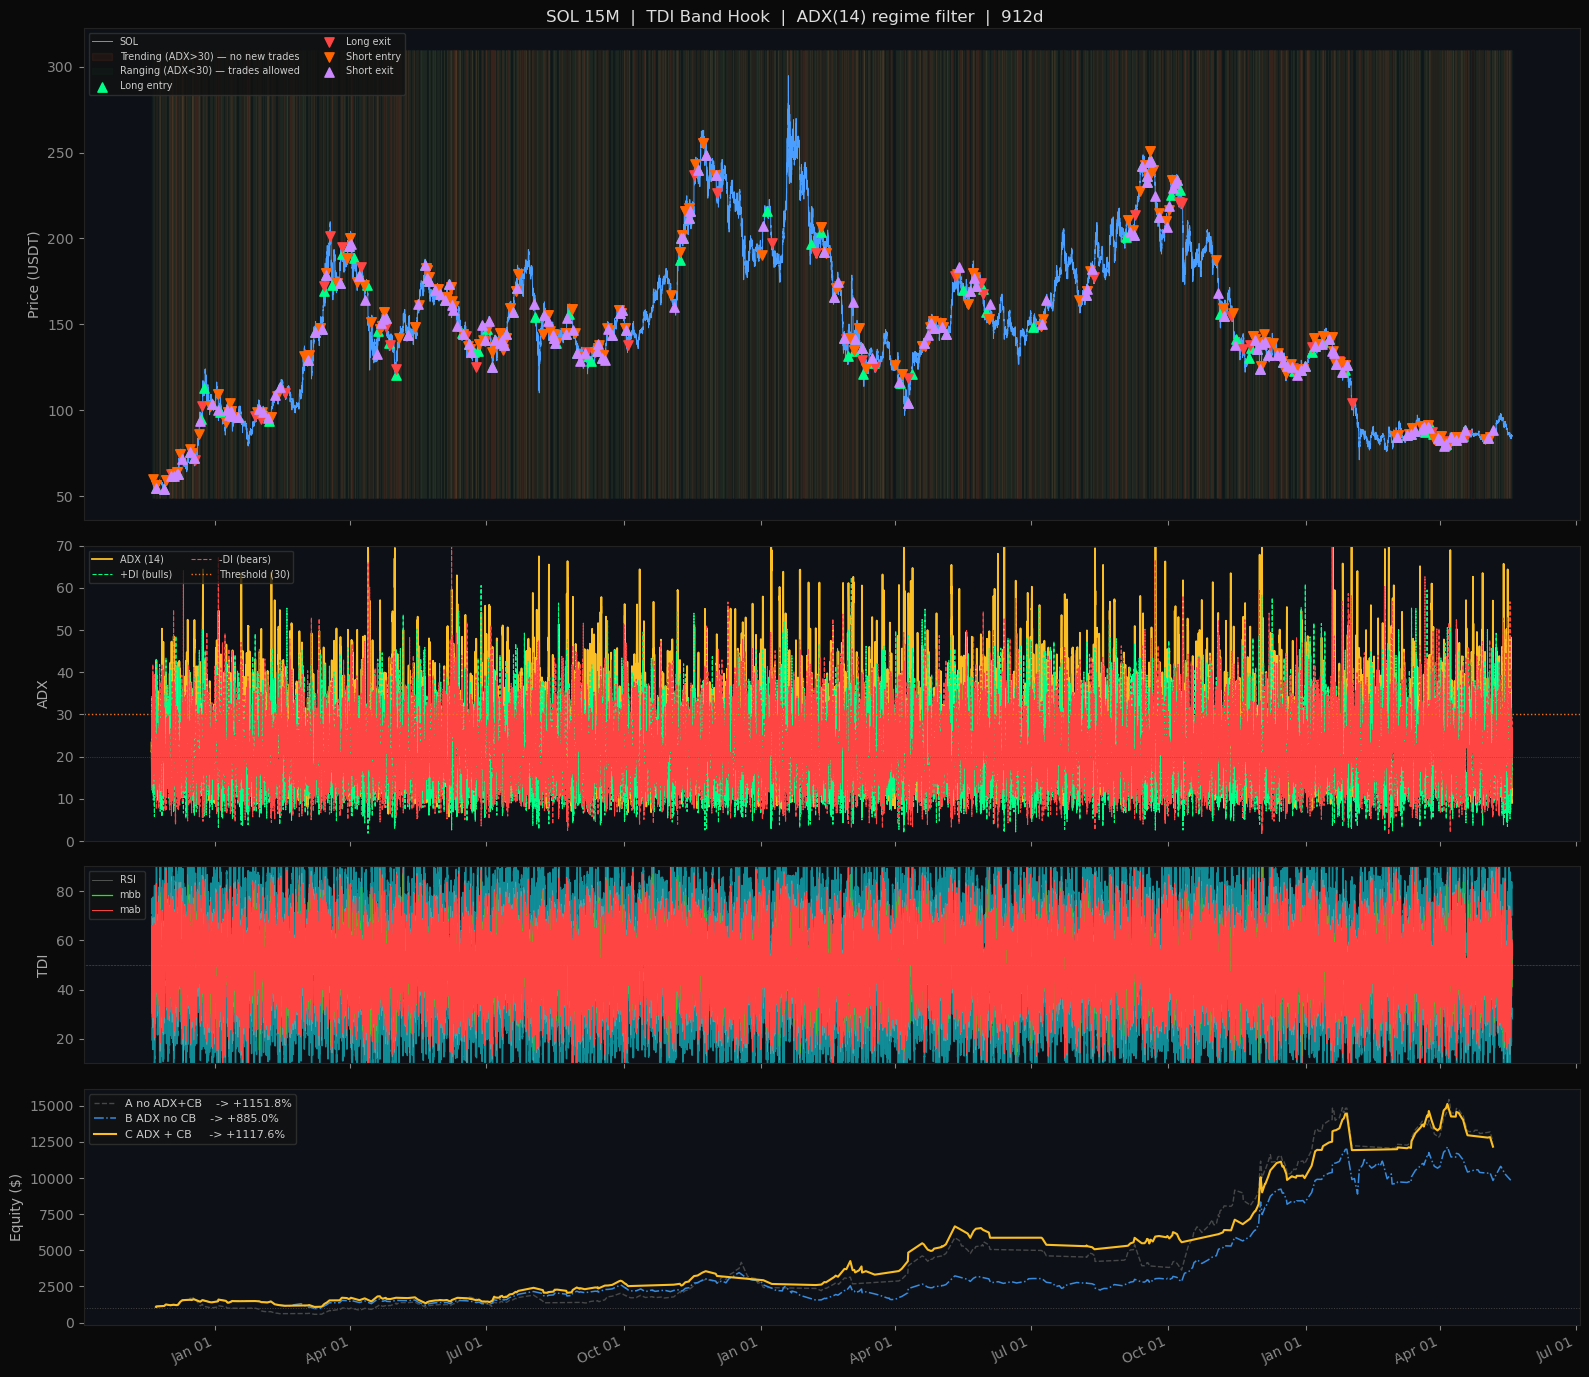

Saved -> sol_adx_filter.png


In [23]:
df_p = tdi.dropna(subset=['r','up','dn','adx'])

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True,
                          gridspec_kw={'height_ratios':[2.5, 1.5, 1, 1.2]})
fig.patch.set_facecolor('#0a0a0a')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#888')
    ax.spines[:].set_color('#222')
fig.suptitle(f'SOL 15M  |  TDI Band Hook  |  ADX({ADX_PERIOD}) regime filter  |  {DAYS}d',
             color='#ddd', fontsize=12)

# ── Price — shade trending vs ranging ──
ax0 = axes[0]
ax0.plot(df_p['ts'], df_p['close'], color='#4a9eff', linewidth=0.7, label='SOL', zorder=3)
# Red shading = trending (ADX filter blocks trades)
ax0.fill_between(df_p['ts'], df_p['close'].min()*0.95, df_p['close'].max()*1.05,
                 where=df_p['trending'],  color='#D85A30', alpha=0.08, label=f'Trending (ADX>{ADX_TREND_THRESH}) — no new trades')
ax0.fill_between(df_p['ts'], df_p['close'].min()*0.95, df_p['close'].max()*1.05,
                 where=~df_p['trending'], color='#1D9E75', alpha=0.04, label=f'Ranging (ADX<{ADX_TREND_THRESH}) — trades allowed')
# Version C trade markers
if len(t_C):
    longs_c  = t_C[t_C['direction']=='long']
    shorts_c = t_C[t_C['direction']=='short']
    if len(longs_c):
        ax0.scatter(longs_c['entry_time'],  longs_c['entry_price'],  marker='^', color='#00ff88', s=45, zorder=5, label='Long entry')
        ax0.scatter(longs_c['exit_time'],   longs_c['exit_price'],   marker='v', color='#ff4444', s=45, zorder=5, label='Long exit')
    if len(shorts_c):
        ax0.scatter(shorts_c['entry_time'], shorts_c['entry_price'], marker='v', color='#ff6600', s=45, zorder=5, label='Short entry')
        ax0.scatter(shorts_c['exit_time'],  shorts_c['exit_price'],  marker='^', color='#cc88ff', s=45, zorder=5, label='Short exit')
ax0.set_ylabel('Price (USDT)', color='#aaa')
ax0.legend(loc='upper left', fontsize=7, ncol=2, facecolor='#111', edgecolor='#333', labelcolor='#ccc')

# ── ADX panel ──
ax1 = axes[1]
ax1.plot(df_p['ts'], df_p['adx'],  color='#fbbf24', linewidth=1.3, label=f'ADX ({ADX_PERIOD})')
ax1.plot(df_p['ts'], df_p['+di'], color='#00ff88', linewidth=0.8, linestyle='--', label='+DI (bulls)')
ax1.plot(df_p['ts'], df_p['-di'], color='#ff4444', linewidth=0.8, linestyle='--', label='-DI (bears)')
ax1.axhline(ADX_TREND_THRESH, color='#f97316', linewidth=1.0, linestyle=':', label=f'Threshold ({ADX_TREND_THRESH})')
ax1.axhline(20, color='#555', linewidth=0.5, linestyle=':')
ax1.fill_between(df_p['ts'], df_p['adx'], ADX_TREND_THRESH,
                 where=df_p['adx'] >= ADX_TREND_THRESH, color='#D85A30', alpha=0.20)
ax1.set_ylabel('ADX', color='#aaa')
ax1.set_ylim(0, 70)
ax1.legend(loc='upper left', fontsize=7, ncol=2, facecolor='#111', edgecolor='#333', labelcolor='#ccc')

# ── TDI panel ──
ax2 = axes[2]
ax2.fill_between(df_p['ts'], df_p['up'], df_p['dn'], alpha=0.06, color='#12bcc9')
ax2.plot(df_p['ts'], df_p['up'],  color='#12bcc9', linewidth=1.0, alpha=0.7)
ax2.plot(df_p['ts'], df_p['dn'],  color='#12bcc9', linewidth=1.0, alpha=0.7)
ax2.plot(df_p['ts'], df_p['r'],   color='#aaa',    linewidth=0.6, alpha=0.5, label='RSI')
ax2.plot(df_p['ts'], df_p['mbb'], color='#00ff00', linewidth=0.9, label='mbb')
ax2.plot(df_p['ts'], df_p['mab'], color='#ff4444', linewidth=0.7, label='mab')
ax2.axhline(50, color='#f97316', linewidth=0.4, linestyle=':')
ax2.set_ylabel('TDI', color='#aaa')
ax2.set_ylim(10, 90)
ax2.legend(loc='upper left', fontsize=7, facecolor='#111', edgecolor='#333', labelcolor='#ccc')

# ── Equity curves ──
ax3 = axes[3]
ax3.plot(t_A['exit_time'], t_A['equity'], color='#555',    linewidth=1.0, linestyle='--', alpha=0.8,
         label=f'A no ADX+CB    -> {(eq_A-CAPITAL)/CAPITAL*100:+.1f}%')
ax3.plot(t_B['exit_time'], t_B['equity'], color='#378ADD', linewidth=1.1, linestyle='-.',
         label=f'B ADX no CB    -> {(eq_B-CAPITAL)/CAPITAL*100:+.1f}%')
ax3.plot(t_C['exit_time'], t_C['equity'], color='#fbbf24', linewidth=1.5,
         label=f'C ADX + CB     -> {(eq_C-CAPITAL)/CAPITAL*100:+.1f}%')
ax3.axhline(CAPITAL, color='#444', linewidth=0.7, linestyle=':')
ax3.set_ylabel('Equity ($)', color='#aaa')
ax3.legend(loc='upper left', fontsize=8, facecolor='#111', edgecolor='#333', labelcolor='#ccc')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.autofmt_xdate(rotation=25)
plt.tight_layout()
plt.savefig('sol_adx_filter.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved -> sol_adx_filter.png")